# EDA cơ bản — PAPILA

Notebook này khám phá bộ dữ liệu **PAPILA v1** trước khi xây dựng mô hình phát hiện glaucoma.

Mục tiêu:

- kiểm tra cấu trúc và tính đầy đủ của dữ liệu;
- mô tả 244 bệnh nhân và 488 mắt/ảnh fundus;
- phân tích phân bố nhãn `Healthy`, `Glaucoma`, `Suspect`;
- khảo sát dữ liệu lâm sàng và giá trị thiếu;
- kiểm tra ảnh fundus và contour optic disc/cup do hai chuyên gia gán nhãn;
- nêu các lưu ý quan trọng trước khi chia train/validation/test.

Nguồn tham khảo: [PAPILA — Scientific Data (2022)](https://doi.org/10.1038/s41597-022-01388-1). Đây là EDA nghiên cứu, không phải công cụ chẩn đoán y khoa.


## 1. Thiết lập môi trường và đường dẫn

Notebook tự tìm root của repository, vì vậy có thể chạy từ thư mục gốc hoặc từ `notebooks/`.


In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def find_repo_root(start: Path) -> Path:
    """Tìm repository chứa data/PAPILA từ vị trí chạy notebook."""
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "data" / "PAPILA").is_dir():
            return candidate
    raise FileNotFoundError(
        "Không tìm thấy data/PAPILA. Hãy giải nén PAPILA vào <repo>/data/PAPILA."
    )


REPO_ROOT = find_repo_root(Path.cwd())
PAPILA_BASE = REPO_ROOT / "data" / "PAPILA"

# Hỗ trợ cả cấu trúc đã flatten và thư mục gốc có tên/hash do Figshare tạo.
if (PAPILA_BASE / "ClinicalData").is_dir():
    PAPILA_ROOT = PAPILA_BASE
else:
    candidates = sorted(
        p for p in PAPILA_BASE.iterdir()
        if p.is_dir()
        and (p / "ClinicalData").is_dir()
        and (p / "FundusImages").is_dir()
    )
    if not candidates:
        raise FileNotFoundError("Không tìm thấy cấu trúc PAPILA đã giải nén.")
    PAPILA_ROOT = candidates[0]

CLINICAL_DIR = PAPILA_ROOT / "ClinicalData"
FUNDUS_DIR = PAPILA_ROOT / "FundusImages"
SEGMENTATION_DIR = PAPILA_ROOT / "ExpertsSegmentations"
CONTOUR_DIR = SEGMENTATION_DIR / "Contours"
CONTOUR_IMAGE_DIR = SEGMENTATION_DIR / "ImagesWithContours"

print(f"Repository : {REPO_ROOT}")
print(f"PAPILA root: {PAPILA_ROOT}")


Repository : /home/dekii2275/Glaucoma-Detection
PAPILA root: /home/dekii2275/Glaucoma-Detection/data/PAPILA/PapilaDB-PAPILA-9c67b80983805f0f886b068af800ef2b507e7dc0


## 2. Kiểm kê dữ liệu

PAPILA cung cấp ảnh fundus của cả mắt phải (`OD`) và mắt trái (`OS`). Với mỗi ảnh có bốn contour: optic cup/disc từ hai chuyên gia.


In [2]:
fundus_paths = sorted(FUNDUS_DIR.glob("*.jpg"))
contour_paths = sorted(CONTOUR_DIR.glob("*.txt"))
contour_image_paths = sorted(CONTOUR_IMAGE_DIR.glob("*.jpg"))
clinical_paths = sorted(CLINICAL_DIR.glob("*.xlsx"))

inventory = pd.DataFrame({
    "Loại dữ liệu": [
        "Bảng clinical (.xlsx)",
        "Ảnh fundus gốc (.jpg)",
        "Contour cup/disc (.txt)",
        "Ảnh có contour (.jpg)",
    ],
    "Số lượng": [
        len(clinical_paths),
        len(fundus_paths),
        len(contour_paths),
        len(contour_image_paths),
    ],
})

display(inventory)
print("Clinical files:", [p.name for p in clinical_paths])
print("Fundus samples:", [p.name for p in fundus_paths[:6]])


,Loại dữ liệu,Số lượng
0,Bảng clinical (.xlsx),2
1,Ảnh fundus gốc (.jpg),488
2,Contour cup/disc (.txt),1952
3,Ảnh có contour (.jpg),488


Clinical files: ['patient_data_od.xlsx', 'patient_data_os.xlsx']
Fundus samples: ['RET002OD.jpg', 'RET002OS.jpg', 'RET004OD.jpg', 'RET004OS.jpg', 'RET005OD.jpg', 'RET005OS.jpg']


## 3. Đọc và chuẩn hóa dữ liệu lâm sàng

Ba dòng đầu của mỗi Excel là header nhiều tầng. Ta đặt lại tên cột rõ ràng và chuyển dữ liệu sang dạng **mỗi dòng = một mắt**.

Mapping theo tài liệu PAPILA:

- `Gender`: 0 = Male, 1 = Female;
- `Diagnosis`: 0 = Healthy, 1 = Glaucoma, 2 = Suspect;
- `Phakic/Pseudophakic`: 0 = Phakic, 1 = Pseudophakic.


In [3]:
CLINICAL_COLUMNS = [
    "patient_id", "age", "gender", "diagnosis", "dioptre_1", "dioptre_2",
    "astigmatism", "lens_status", "iop_pneumatic", "iop_perkins",
    "pachymetry", "axial_length", "vf_md",
]
NUMERIC_COLUMNS = CLINICAL_COLUMNS[1:]

DIAGNOSIS_MAP = {0: "Healthy", 1: "Glaucoma", 2: "Suspect"}
GENDER_MAP = {0: "Male", 1: "Female"}
LENS_MAP = {0: "Phakic", 1: "Pseudophakic"}
DIAGNOSIS_ORDER = ["Healthy", "Glaucoma", "Suspect"]
DIAGNOSIS_COLORS = {
    "Healthy": "#2A9D8F",
    "Glaucoma": "#E76F51",
    "Suspect": "#E9C46A",
}


def read_eye_table(path: Path, eye: str) -> pd.DataFrame:
    """Đọc một bảng OD/OS và trả về schema phẳng, nhất quán."""
    df = pd.read_excel(
        path,
        header=None,
        skiprows=3,
        names=CLINICAL_COLUMNS,
        engine="openpyxl",
    ).dropna(how="all")

    df["patient_id"] = (
        df["patient_id"].astype(str)
        .str.replace("#", "", regex=False)
        .str.strip()
        .str.zfill(3)
    )
    for column in NUMERIC_COLUMNS:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    df["eye"] = eye
    df["image_id"] = "RET" + df["patient_id"] + eye
    df["image_name"] = df["image_id"] + ".jpg"
    df["diagnosis_label"] = df["diagnosis"].map(DIAGNOSIS_MAP)
    df["gender_label"] = df["gender"].map(GENDER_MAP)
    df["lens_label"] = df["lens_status"].map(LENS_MAP)
    return df


od_df = read_eye_table(CLINICAL_DIR / "patient_data_od.xlsx", "OD")
os_df = read_eye_table(CLINICAL_DIR / "patient_data_os.xlsx", "OS")
eye_df = pd.concat([od_df, os_df], ignore_index=True)
eye_df = eye_df.sort_values(["patient_id", "eye"]).reset_index(drop=True)

display(eye_df.head())
print(f"Số bệnh nhân: {eye_df['patient_id'].nunique():,}")
print(f"Số mắt/bản ghi: {len(eye_df):,}")


,patient_id,age,gender,diagnosis,dioptre_1,dioptre_2,astigmatism,lens_status,iop_pneumatic,iop_perkins,pachymetry,axial_length,vf_md,eye,image_id,image_name,diagnosis_label,gender_label,lens_label
0,002,47,0,2,0.75,-1.75,90.0,0.0,21.0,NaN,586.0,23.64,-0.07,OD,RET002OD,RET002OD.jpg,Suspect,Male,Phakic
1,002,47,0,2,-0.50,-1.50,88.0,0.0,20.0,NaN,603.0,23.77,0.17,OS,RET002OS,RET002OS.jpg,Suspect,Male,Phakic
2,004,58,1,1,1.50,-1.75,85.0,0.0,NaN,19.0,501.0,23.06,-3.26,OD,RET004OD,RET004OD.jpg,Glaucoma,Female,Phakic
3,004,58,1,1,1.50,-2.50,85.0,1.0,NaN,19.0,511.0,22.96,-6.77,OS,RET004OS,RET004OS.jpg,Glaucoma,Female,Pseudophakic
4,005,89,1,1,-0.75,-1.25,101.0,1.0,13.0,14.0,565.0,23.81,-14.98,OD,RET005OD,RET005OD.jpg,Glaucoma,Female,Pseudophakic


Số bệnh nhân: 244
Số mắt/bản ghi: 488


## 4. Kiểm tra chất lượng và liên kết tệp

Các kiểm tra dưới đây phát hiện bản ghi trùng, ảnh thiếu, nhãn ngoài mapping và contour thiếu/dư trước khi phân tích.


In [4]:
expected_contours = [
    CONTOUR_DIR / f"{image_id}_{structure}_exp{expert}.txt"
    for image_id in eye_df["image_id"]
    for structure in ("cup", "disc")
    for expert in (1, 2)
]

quality_checks = pd.Series({
    "Duplicate patient-eye records": int(eye_df.duplicated(["patient_id", "eye"]).sum()),
    "Missing fundus images": int((~eye_df["image_name"].map(lambda x: (FUNDUS_DIR / x).is_file())).sum()),
    "Unknown diagnosis labels": int(eye_df["diagnosis_label"].isna().sum()),
    "Missing expected contours": int(sum(not p.is_file() for p in expected_contours)),
    "Unexpected/extra contours": int(len(contour_paths) - len(expected_contours)),
}, name="Count").to_frame()

display(quality_checks)
assert quality_checks.loc[
    ["Duplicate patient-eye records", "Missing fundus images", "Unknown diagnosis labels", "Missing expected contours"],
    "Count",
].sum() == 0, "Phát hiện lỗi liên kết dữ liệu; xem bảng quality_checks."


,Count
Duplicate patient-eye records,0
Missing fundus images,0
Unknown diagnosis labels,0
Missing expected contours,0
Unexpected/extra contours,0


## 5. Phân bố chẩn đoán theo mắt

Đơn vị ở đây là **mắt/ảnh**, không phải bệnh nhân. Cần giữ ba lớp riêng trong EDA vì `Suspect` là một nhãn độc lập trong PAPILA.


,Eyes,Percent
diagnosis_label,,
Healthy,333,68.2
Glaucoma,87,17.8
Suspect,68,13.9


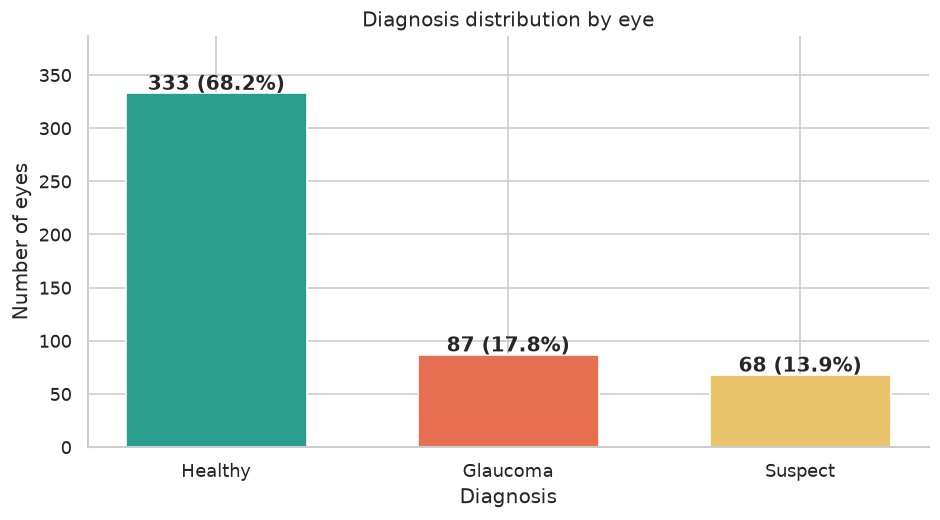

In [5]:
class_counts = eye_df["diagnosis_label"].value_counts().reindex(DIAGNOSIS_ORDER, fill_value=0)
class_pct = (class_counts / class_counts.sum() * 100).round(1)
class_table = pd.DataFrame({"Eyes": class_counts, "Percent": class_pct})
display(class_table)

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(
    class_counts.index,
    class_counts.values,
    color=[DIAGNOSIS_COLORS[x] for x in class_counts.index],
    width=0.62,
)
for bar, count, pct in zip(bars, class_counts, class_pct):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        f"{count} ({pct:.1f}%)",
        ha="center",
        fontweight="bold",
    )
ax.set(title="Diagnosis distribution by eye", xlabel="Diagnosis", ylabel="Number of eyes")
ax.set_ylim(0, class_counts.max() * 1.16)
plt.tight_layout()
plt.show()


## 6. Quan hệ giữa hai mắt của cùng bệnh nhân

Bảng chéo OD–OS giúp thấy số bệnh nhân có cùng hoặc khác chẩn đoán giữa hai mắt. Đây cũng là lý do phải chia dữ liệu ở **patient level**, không chia ngẫu nhiên theo ảnh.


In [6]:
bilateral = eye_df.pivot(index="patient_id", columns="eye", values="diagnosis_label").reindex(columns=["OD", "OS"])
bilateral_table = pd.crosstab(bilateral["OD"], bilateral["OS"]).reindex(
    index=DIAGNOSIS_ORDER,
    columns=DIAGNOSIS_ORDER,
    fill_value=0,
)

display(bilateral_table.style.background_gradient(cmap="Blues"))
print(f"Bệnh nhân có chẩn đoán khác nhau giữa hai mắt: {(bilateral['OD'] != bilateral['OS']).sum()} / {len(bilateral)}")


OS,Healthy,Glaucoma,Suspect
OD,,,
Healthy,163,7,0
Glaucoma,0,40,0
Suspect,0,0,34


Bệnh nhân có chẩn đoán khác nhau giữa hai mắt: 7 / 244


## 7. Tuổi và giới tính

Tuổi và giới tính là thuộc tính bệnh nhân nên chỉ lấy một dòng cho mỗi `patient_id`, tránh đếm hai lần vì mỗi bệnh nhân có hai mắt.


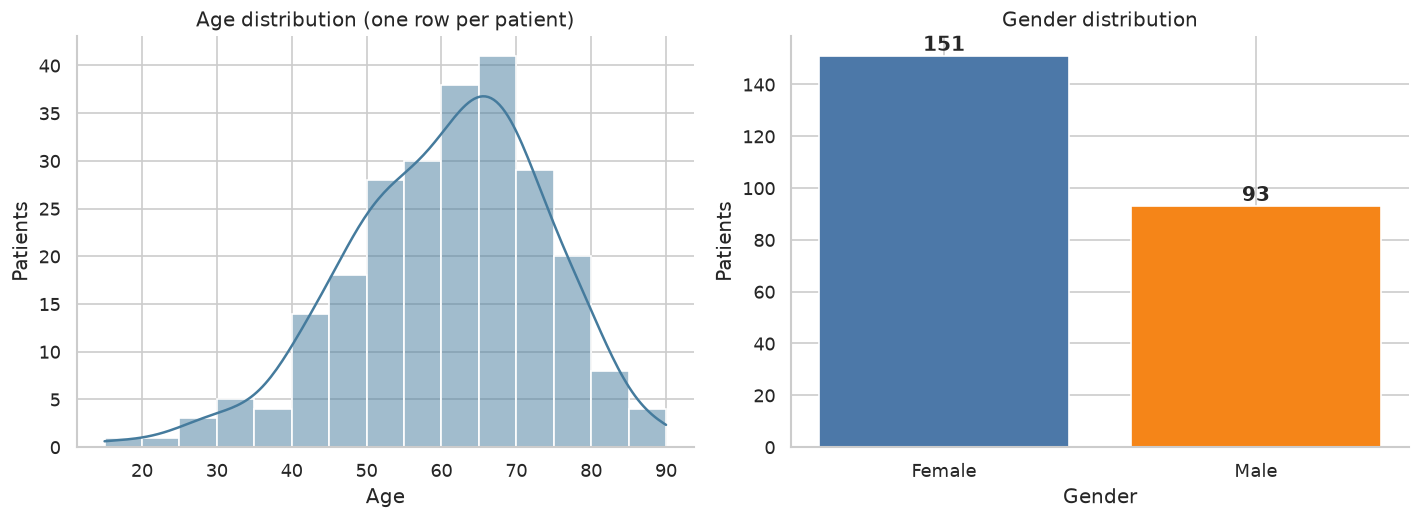

,count,mean,std,min,25%,50%,75%,max
age,244.0,60.59,13.08,15.0,52.0,62.0,69.25,90.0


In [7]:
patient_df = (
    eye_df.sort_values(["patient_id", "eye"])
    .drop_duplicates("patient_id")
    [["patient_id", "age", "gender_label"]]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(patient_df, x="age", bins=15, kde=True, color="#457B9D", ax=axes[0])
axes[0].set(title="Age distribution (one row per patient)", xlabel="Age", ylabel="Patients")

gender_counts = patient_df["gender_label"].value_counts()
axes[1].bar(gender_counts.index, gender_counts.values, color=["#4C78A8", "#F58518"])
for i, value in enumerate(gender_counts.values):
    axes[1].text(i, value + 2, str(value), ha="center", fontweight="bold")
axes[1].set(title="Gender distribution", xlabel="Gender", ylabel="Patients")

plt.tight_layout()
plt.show()
display(patient_df[["age"]].describe().T.round(2))


## 8. Giá trị thiếu trong dữ liệu lâm sàng

Không nên tự động điền giá trị trước khi xem mức độ thiếu. Hai phép đo IOP (`Pneumatic`, `Perkins`) có thể không đồng thời hiện diện.


,Missing,Missing (%)
iop_perkins,360,73.8
vf_md,324,66.4
iop_pneumatic,92,18.9
dioptre_1,27,5.5
pachymetry,14,2.9
lens_status,11,2.3
astigmatism,9,1.8
axial_length,9,1.8
dioptre_2,8,1.6


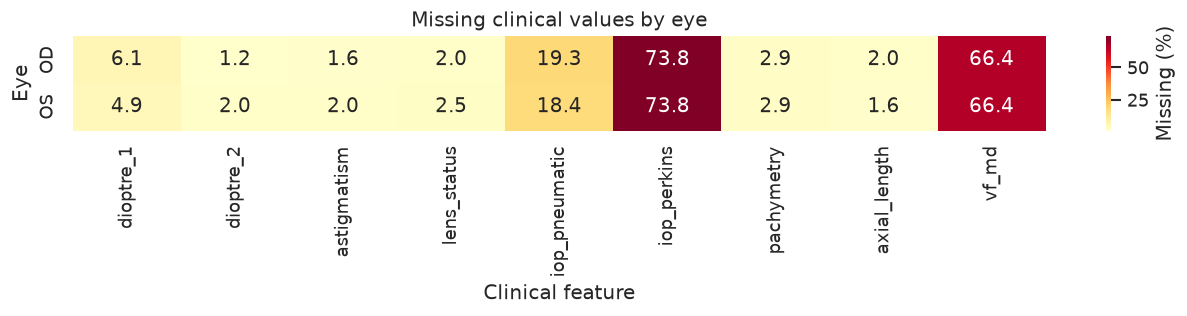

In [8]:
clinical_features = [
    "dioptre_1", "dioptre_2", "astigmatism", "lens_status",
    "iop_pneumatic", "iop_perkins", "pachymetry", "axial_length", "vf_md",
]

missing_table = pd.DataFrame({
    "Missing": eye_df[clinical_features].isna().sum(),
    "Missing (%)": (eye_df[clinical_features].isna().mean() * 100).round(1),
}).sort_values("Missing (%)", ascending=False)
display(missing_table)

missing_by_eye = eye_df.groupby("eye")[clinical_features].apply(lambda frame: frame.isna().mean() * 100)
fig, ax = plt.subplots(figsize=(11, 2.8))
sns.heatmap(missing_by_eye, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={"label": "Missing (%)"}, ax=ax)
ax.set(title="Missing clinical values by eye", xlabel="Clinical feature", ylabel="Eye")
plt.tight_layout()
plt.show()


## 9. Phân bố các chỉ số lâm sàng theo chẩn đoán

Các biểu đồ dưới đây chỉ mang tính mô tả. Không dùng khác biệt quan sát được trong EDA như bằng chứng quan hệ nhân quả hoặc kết luận y khoa.


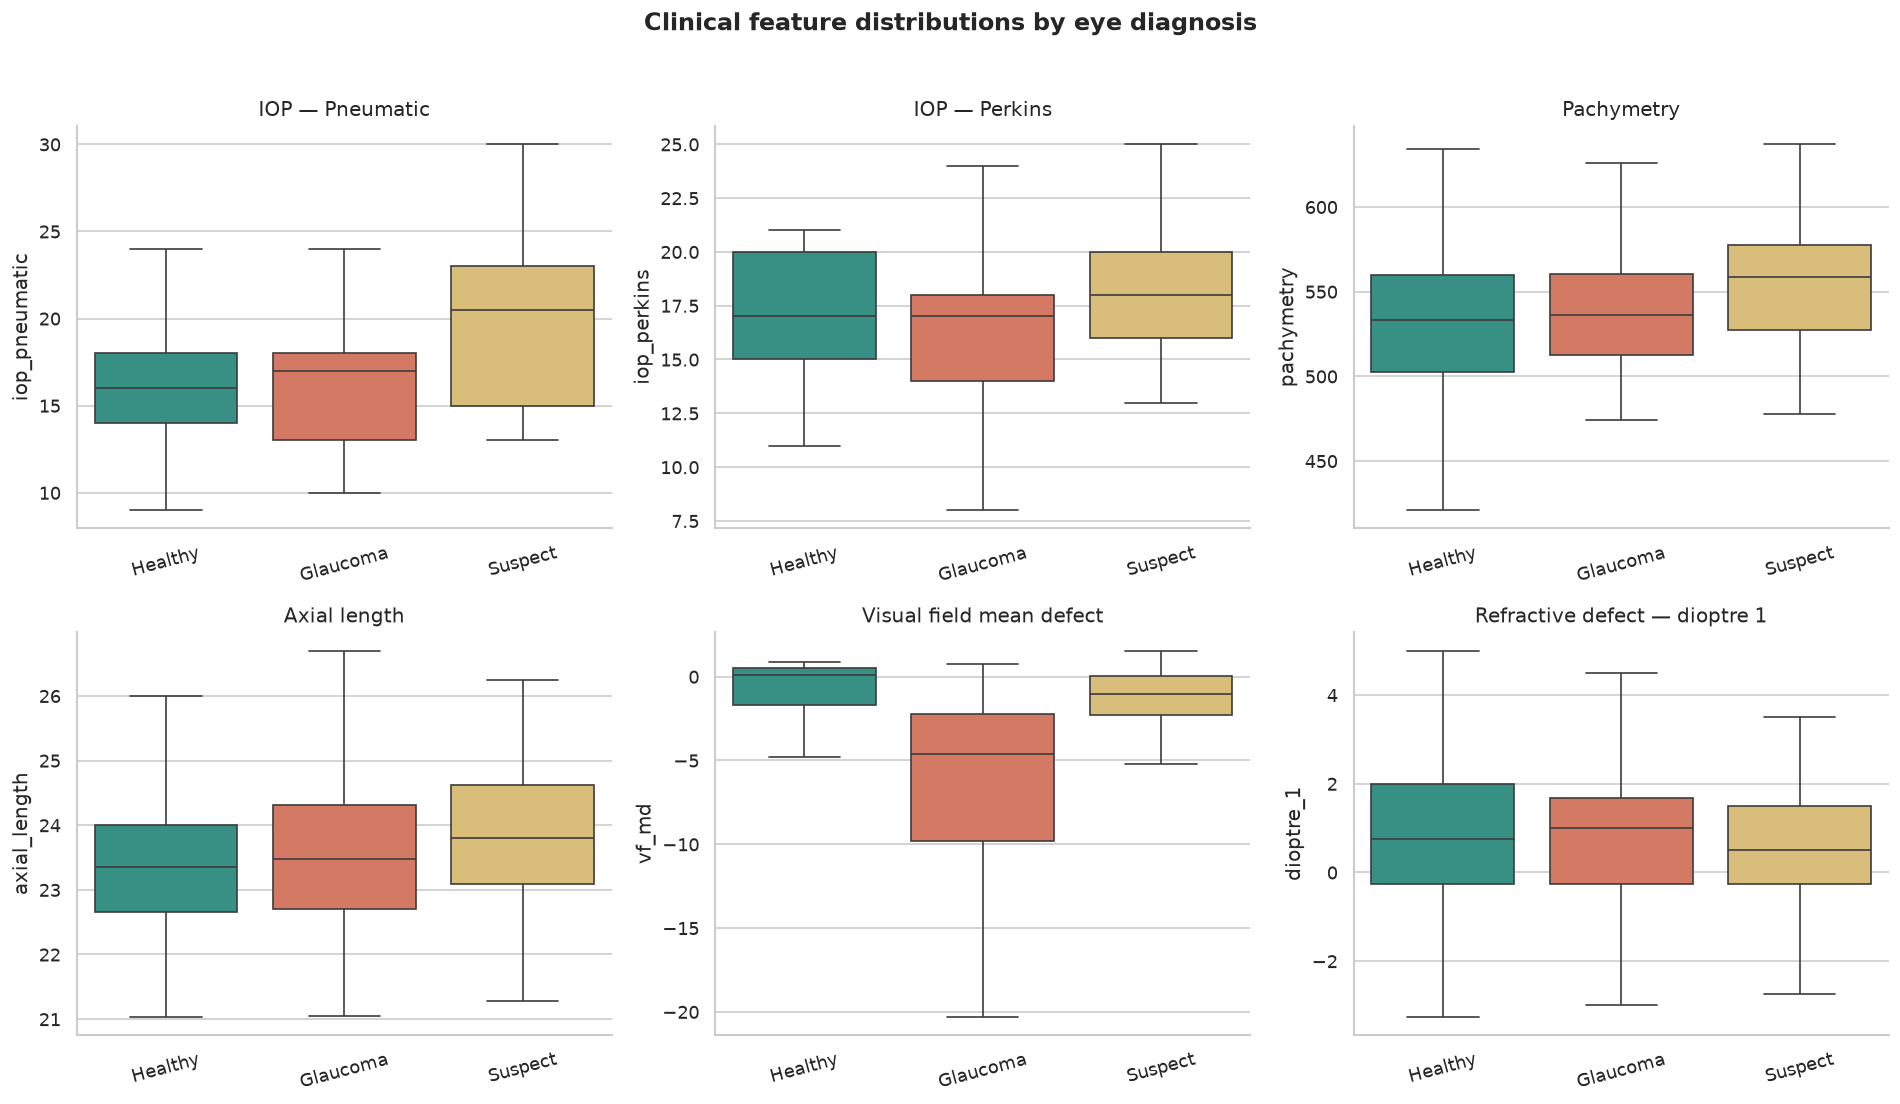

In [9]:
plot_features = {
    "iop_pneumatic": "IOP — Pneumatic",
    "iop_perkins": "IOP — Perkins",
    "pachymetry": "Pachymetry",
    "axial_length": "Axial length",
    "vf_md": "Visual field mean defect",
    "dioptre_1": "Refractive defect — dioptre 1",
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (feature, title) in zip(axes.flat, plot_features.items()):
    sns.boxplot(
        data=eye_df,
        x="diagnosis_label",
        y=feature,
        order=DIAGNOSIS_ORDER,
        hue="diagnosis_label",
        palette=DIAGNOSIS_COLORS,
        legend=False,
        showfliers=False,
        ax=ax,
    )
    ax.set(title=title, xlabel="", ylabel=feature)
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Clinical feature distributions by eye diagnosis", y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()


## 10. Thuộc tính và khả năng đọc của ảnh fundus

Bước này kiểm tra toàn bộ ảnh, nhưng chỉ đọc metadata ảnh nên tương đối nhanh.


In [10]:
image_records = []
corrupt_images = []

for path in fundus_paths:
    try:
        with Image.open(path) as image:
            image_records.append({
                "image_name": path.name,
                "width": image.width,
                "height": image.height,
                "mode": image.mode,
                "size_mb": path.stat().st_size / (1024 ** 2),
            })
            image.verify()
    except Exception as exc:
        corrupt_images.append((path.name, str(exc)))

image_df = pd.DataFrame(image_records)
resolution_counts = image_df.value_counts(["width", "height", "mode"]).rename("count").reset_index()

display(resolution_counts)
display(image_df["size_mb"].describe().round(3).to_frame("Image size (MiB)").T)
print(f"Ảnh lỗi/không đọc được: {len(corrupt_images)}")
if corrupt_images:
    display(pd.DataFrame(corrupt_images, columns=["image_name", "error"]))


,width,height,mode,count
0,2576,1934,RGB,488


,count,mean,std,min,25%,50%,75%,max
Image size (MiB),488.0,1.033,0.061,0.799,1.02,1.045,1.067,1.142


Ảnh lỗi/không đọc được: 0


## 11. Ảnh mẫu theo chẩn đoán


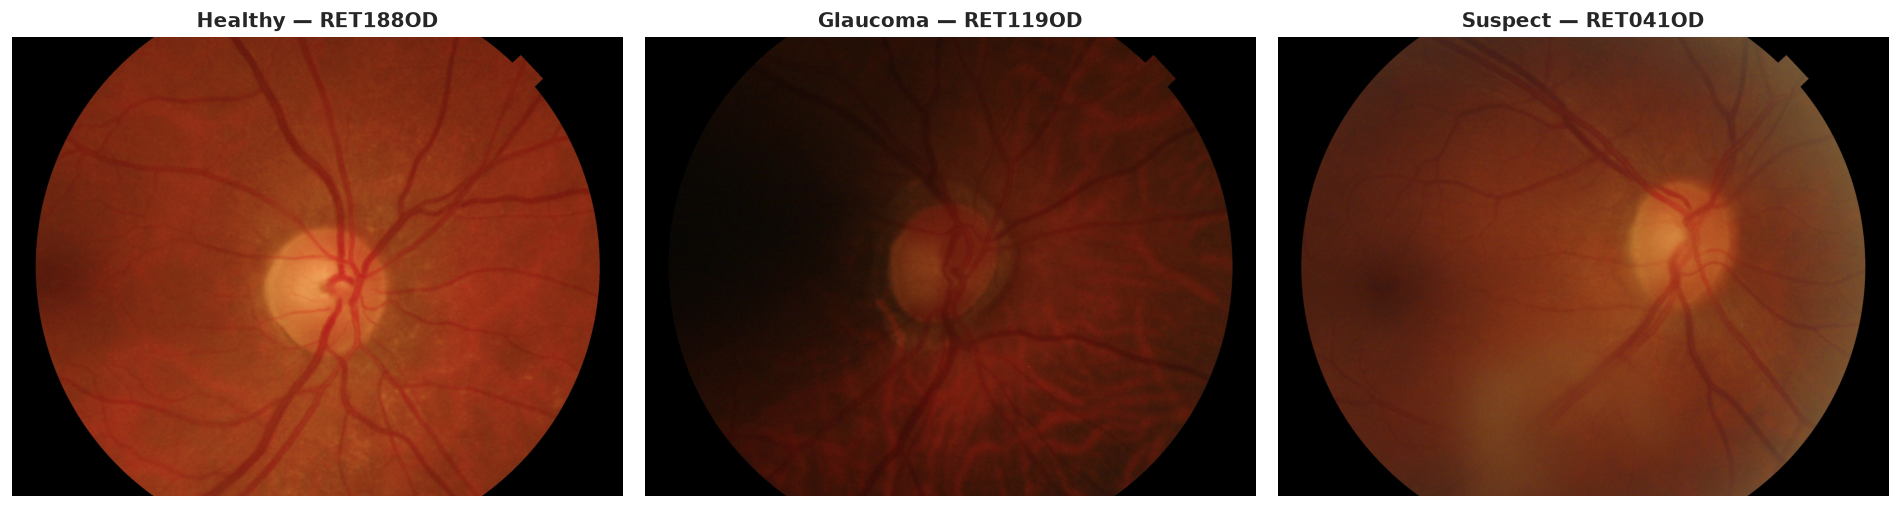

In [11]:
samples = (
    eye_df.groupby("diagnosis_label", group_keys=False)
    .sample(n=1, random_state=42)
    .set_index("diagnosis_label")
    .reindex(DIAGNOSIS_ORDER)
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (_, row) in zip(axes, samples.iterrows()):
    with Image.open(FUNDUS_DIR / row["image_name"]) as image:
        ax.imshow(image.convert("RGB"))
    ax.set_title(f"{row['diagnosis_label']} — {row['image_id']}", fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.show()


## 12. Contour optic disc/cup và mức đồng thuận giữa hai chuyên gia

`area_cdr` dưới đây là **tỉ lệ diện tích cup/disc**, không phải vertical CDR lâm sàng. Chỉ số được dùng để kiểm tra dữ liệu và so sánh mô tả giữa hai expert.


Contour hợp lệ: 1,952
Tên contour không đúng quy ước: 0


cup                                                                  \
        count       mean        std       min       25%        50%        75%   
expert                                                                          
1       488.0  26659.907  22178.611  1348.099  9964.774  22347.815  35408.515   
2       488.0  25188.540  22528.186  1386.711  9564.570  19327.574  33705.947   

                    disc              ...                         area_cdr  \
              max  count        mean  ...         75%         max    count   
expert                                ...                                    
1       135934.20  488.0  172901.464  ...  191130.976  308075.858    488.0   
2       132806.75  488.0  157268.641  ...  175801.797  262279.804    488.0   

                                                         
         mean    std    min    25%    50%    75%    max  
expert                                                   
1       0.151  0.117  0.009  0.065  0.125  0.204  0.683  
2       0.153  0.121  0.009  0.066  0.123  0.204  0.671  

[2 rows x 24 columns]

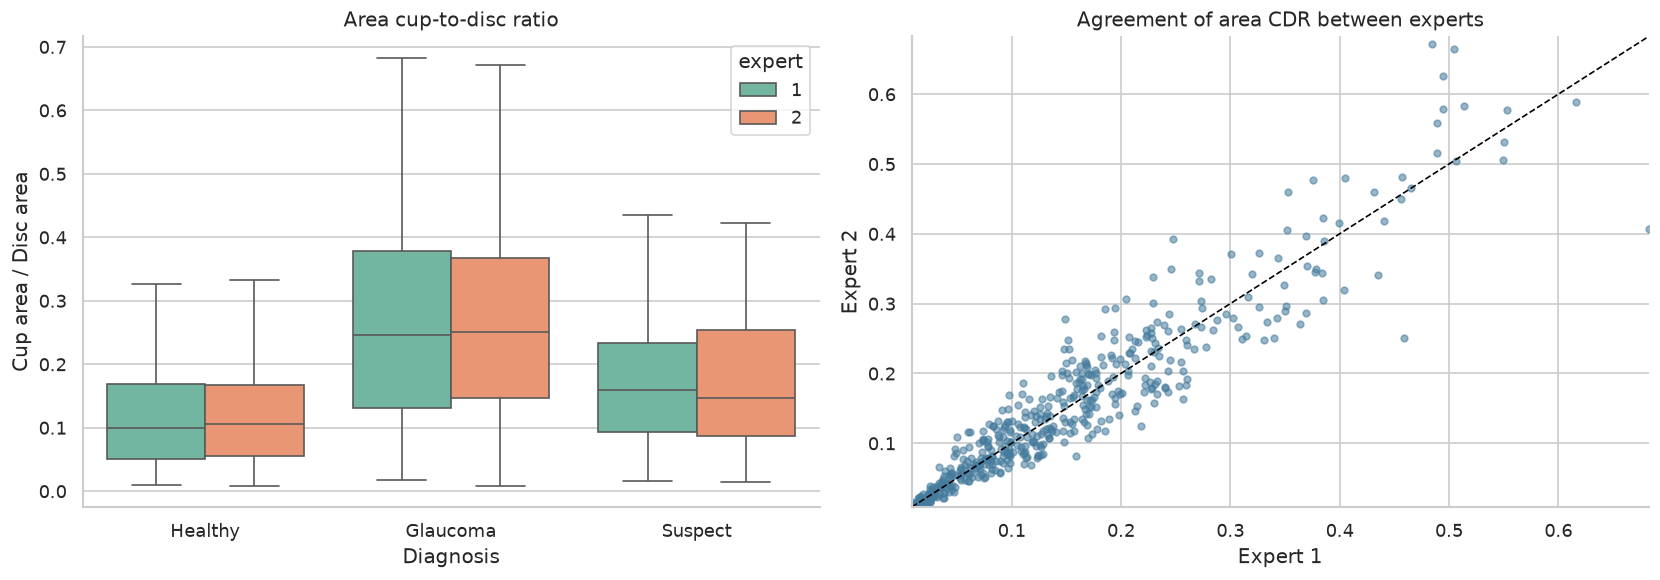

Pearson correlation (area CDR): 0.941


In [12]:
CONTOUR_PATTERN = re.compile(
    r"^(?P<image_id>RET\d+(?:OD|OS))_(?P<structure>cup|disc)_exp(?P<expert>[12])\.txt$"
)


def polygon_area(points: np.ndarray) -> float:
    """Diện tích polygon theo công thức shoelace; points có thứ tự (x, y)."""
    x, y = points[:, 0], points[:, 1]
    return 0.5 * abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))


area_records = []
invalid_contours = []
for path in contour_paths:
    match = CONTOUR_PATTERN.match(path.name)
    if match is None:
        invalid_contours.append(path.name)
        continue
    points = np.loadtxt(path)
    area_records.append({
        **match.groupdict(),
        "area_px": polygon_area(points),
        "n_points": len(points),
    })

contour_df = pd.DataFrame(area_records)
contour_df["expert"] = contour_df["expert"].astype(int)
area_df = contour_df.pivot_table(
    index=["image_id", "expert"], columns="structure", values="area_px", aggfunc="first"
).reset_index()
area_df["area_cdr"] = area_df["cup"] / area_df["disc"]
area_df = area_df.merge(
    eye_df[["image_id", "diagnosis_label"]], on="image_id", how="left", validate="many_to_one"
)

print(f"Contour hợp lệ: {len(contour_df):,}")
print(f"Tên contour không đúng quy ước: {len(invalid_contours):,}")
display(area_df.groupby("expert")[["cup", "disc", "area_cdr"]].describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(
    data=area_df,
    x="diagnosis_label",
    y="area_cdr",
    hue="expert",
    order=DIAGNOSIS_ORDER,
    palette="Set2",
    showfliers=False,
    ax=axes[0],
)
axes[0].set(title="Area cup-to-disc ratio", xlabel="Diagnosis", ylabel="Cup area / Disc area")

expert_pivot = area_df.pivot(index="image_id", columns="expert", values="area_cdr").dropna()
axes[1].scatter(expert_pivot[1], expert_pivot[2], s=16, alpha=0.55, color="#457B9D")
limits = [expert_pivot.min().min(), expert_pivot.max().max()]
axes[1].plot(limits, limits, "--", color="black", linewidth=1)
axes[1].set(
    title="Agreement of area CDR between experts",
    xlabel="Expert 1",
    ylabel="Expert 2",
    xlim=limits,
    ylim=limits,
)

plt.tight_layout()
plt.show()
print(f"Pearson correlation (area CDR): {expert_pivot[1].corr(expert_pivot[2]):.3f}")


## 13. Trực quan contour từ hai chuyên gia

- Đỏ: optic cup; xanh: optic disc.
- Nét liền: Expert 1; nét đứt: Expert 2.
- Hình được crop quanh vùng optic nerve head để dễ quan sát.


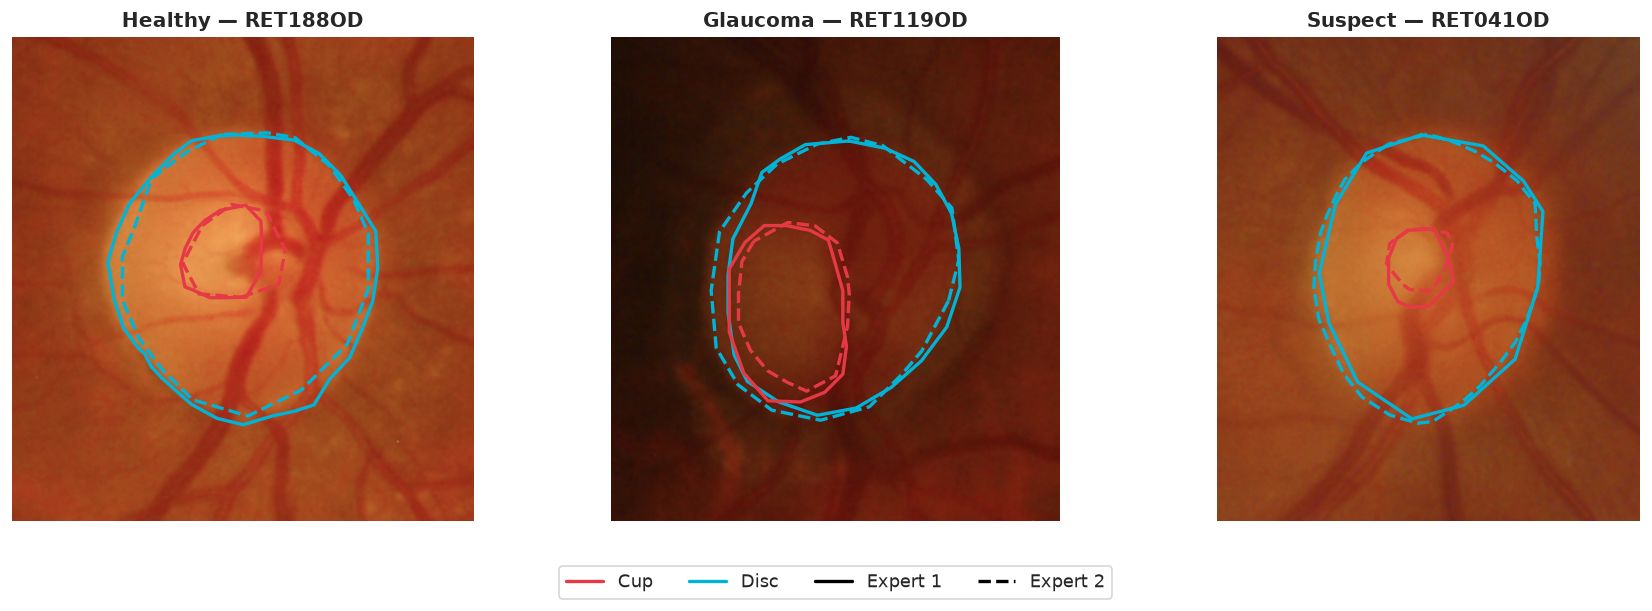

In [13]:
def plot_contour_crop(ax, image_id: str, diagnosis: str, margin: int = 180) -> None:
    with Image.open(FUNDUS_DIR / f"{image_id}.jpg") as image:
        rgb = np.asarray(image.convert("RGB"))

    all_points = []
    styles = {
        ("disc", 1): ("#00B4D8", "-"),
        ("disc", 2): ("#00B4D8", "--"),
        ("cup", 1): ("#E63946", "-"),
        ("cup", 2): ("#E63946", "--"),
    }
    ax.imshow(rgb)
    for (structure, expert), (color, linestyle) in styles.items():
        path = CONTOUR_DIR / f"{image_id}_{structure}_exp{expert}.txt"
        points = np.loadtxt(path)
        closed = np.vstack([points, points[0]])
        ax.plot(closed[:, 0], closed[:, 1], color=color, linestyle=linestyle, linewidth=2)
        all_points.append(points)

    stacked = np.vstack(all_points)
    height, width = rgb.shape[:2]
    x_min = max(0, stacked[:, 0].min() - margin)
    x_max = min(width, stacked[:, 0].max() + margin)
    y_min = max(0, stacked[:, 1].min() - margin)
    y_max = min(height, stacked[:, 1].max() + margin)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_max, y_min)
    ax.set_title(f"{diagnosis} — {image_id}", fontweight="bold")
    ax.axis("off")


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (_, row) in zip(axes, samples.iterrows()):
    plot_contour_crop(ax, row["image_id"], row["diagnosis_label"])

legend_handles = [
    Line2D([0], [0], color="#E63946", lw=2, label="Cup"),
    Line2D([0], [0], color="#00B4D8", lw=2, label="Disc"),
    Line2D([0], [0], color="black", lw=2, linestyle="-", label="Expert 1"),
    Line2D([0], [0], color="black", lw=2, linestyle="--", label="Expert 2"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.03))
plt.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()


## 14. Tổng kết tự động

Bảng sau lấy trực tiếp từ dữ liệu thay vì hard-code, nhờ đó vẫn đúng nếu dữ liệu được thay đổi hoặc cập nhật.


In [14]:
summary = pd.DataFrame({
    "Metric": [
        "Patients",
        "Eyes / fundus images",
        "Healthy eyes",
        "Glaucoma eyes",
        "Suspect eyes",
        "Patients with discordant OD/OS diagnoses",
        "Corrupt fundus images",
        "Missing expected contours",
        "Contour annotations",
    ],
    "Value": [
        eye_df["patient_id"].nunique(),
        len(eye_df),
        class_counts["Healthy"],
        class_counts["Glaucoma"],
        class_counts["Suspect"],
        int((bilateral["OD"] != bilateral["OS"]).sum()),
        len(corrupt_images),
        int(quality_checks.loc["Missing expected contours", "Count"]),
        len(contour_df),
    ],
})
display(summary.style.hide(axis="index"))


Metric,Value
Patients,244
Eyes / fundus images,488
Healthy eyes,333
Glaucoma eyes,87
Suspect eyes,68
Patients with discordant OD/OS diagnoses,7
Corrupt fundus images,0
Missing expected contours,0
Contour annotations,1952


## 15. Lưu ý trước khi modeling

1. **Chia dữ liệu theo bệnh nhân:** OD và OS của cùng bệnh nhân phải luôn nằm trong cùng một split để tránh data leakage.
2. **Xác định bài toán nhãn trước:** giữ ba lớp (`Healthy`, `Glaucoma`, `Suspect`) cho multiclass; nếu làm binary, cần ghi rõ cách xử lý `Suspect` thay vì gộp tùy ý.
3. **Xử lý missing theo train split:** chỉ fit chiến lược imputation trên tập train, sau đó áp dụng cho validation/test.
4. **Giữ thông tin expert:** contour từ hai chuyên gia không hoàn toàn giống nhau; cần định nghĩa ground truth trước khi huấn luyện segmentation.
5. **Đánh giá theo bệnh nhân và theo mắt:** nên báo cáo rõ đơn vị dự đoán và đơn vị tính metric.
6. **EDA không phải suy luận y khoa:** các quan hệ quan sát được trong bộ dữ liệu nhỏ này không tự động khái quát cho quần thể khác.
